# Auto-encodeur convolutif — Détection d'anomalies

## Principe
1. On entraîne un **auto-encodeur convolutionnel** UNIQUEMENT sur les images "good" (normales)
2. Le modèle apprend à **compresser puis reconstruire** les images normales
3. À l'inférence, une image **anormale** sera mal reconstruite → **erreur de reconstruction élevée**
4. On utilise l'erreur MSE par pixel comme **carte d'anomalie** (heatmap)

## Dataset
- **Source** : `Dataset_128/` (images 128×128 préparées)
- **Train** : uniquement des images "good"
- **Test** : images good + defective
- On travaille **catégorie par catégorie**

## Objectif
- Implémenter un CNN from scratch (non supervisé)
- Mesurer les performances (AUC ROC)
- Visualiser les cartes d'erreur
- **Résultat attendu** : performances moyennes (AUC ~0.65-0.85 selon catégorie)

In [1]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers

# Seeds
np.random.seed(42)
tf.random.set_seed(42)

# Style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

print(f"✅ TensorFlow {tf.__version__}")
print(f"   GPU disponible : {tf.config.list_physical_devices('GPU')}")

✅ TensorFlow 2.21.0
   GPU disponible : []


In [2]:
# ⚙️ Paramètres
BASE_DIR = "Dataset_128"                # Dataset préparé
IMG_SIZE = 128                          # 128×128
BATCH_SIZE = 32
EPOCHS = 100
LATENT_DIM = 512                        # Taille du goulot d'étranglement (bottleneck)

# 15 catégories MVTec AD
CATEGORIES = [
    "bottle", "cable", "capsule", "carpet", "grid",
    "hazelnut", "leather", "metal_nut", "pill", "screw",
    "tile", "toothbrush", "transistor", "wood", "zipper"
]

print(f"📁 Dataset   : {BASE_DIR}/")
print(f"📏 Taille    : {IMG_SIZE}×{IMG_SIZE}")
print(f"🔢 Batch     : {BATCH_SIZE}")
print(f"🔄 Epochs    : {EPOCHS}")
print(f"🧬 Bottleneck: {LATENT_DIM}")
print(f"📂 Catégories: {len(CATEGORIES)}")

📁 Dataset   : Dataset_128/
📏 Taille    : 128×128
🔢 Batch     : 32
🔄 Epochs    : 100
🧬 Bottleneck: 512
📂 Catégories: 15


## 1. Chargement des données

In [3]:
def load_images_from_folder(folder, img_size=(IMG_SIZE, IMG_SIZE)):
    """Charge toutes les images d'un dossier et les normalise en [0,1]."""
    images = []
    for fname in sorted(os.listdir(folder)):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            path = os.path.join(folder, fname)
            img = keras.utils.load_img(path, target_size=img_size, color_mode='rgb')
            img = keras.utils.img_to_array(img) / 255.0
            images.append(img)
    return np.array(images)

def load_category(base_dir, category):
    """Charge train (good) et test (good + defective) pour une catégorie."""
    # Train
    train_dir = os.path.join(base_dir, "Train", category, "good")
    X_train = load_images_from_folder(train_dir)
    
    # Test
    test_dir = os.path.join(base_dir, "Test", category)
    X_test, y_test = [], []
    for defect_type in sorted(os.listdir(test_dir)):
        folder = os.path.join(test_dir, defect_type)
        if not os.path.isdir(folder): continue
        imgs = load_images_from_folder(folder)
        X_test.append(imgs)
        label = 0 if defect_type == "good" else 1
        y_test.extend([label] * len(imgs))
    
    X_test = np.concatenate(X_test, axis=0)
    y_test = np.array(y_test)
    return X_train, X_test, y_test

print("✅ Fonctions de chargement prêtes")

✅ Fonctions de chargement prêtes


## 2. Architecture de l'auto-encodeur

In [4]:
def build_autoencoder(input_shape=(IMG_SIZE, IMG_SIZE, 3), latent_dim=LATENT_DIM):
    """Auto-encodeur convolutionnel avec BatchNorm et LeakyReLU."""
    
    # ---- Encoder ----
    encoder_input = layers.Input(shape=input_shape, name="encoder_input")
    
    x = layers.Conv2D(32, 4, strides=2, padding='same', name="conv1")(encoder_input)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    
    x = layers.Conv2D(64, 4, strides=2, padding='same', name="conv2")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    
    x = layers.Conv2D(128, 4, strides=2, padding='same', name="conv3")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    
    x = layers.Conv2D(256, 4, strides=2, padding='same', name="conv4")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    
    # Goulot d'étranglement (bottleneck) :  8×8×256 → vecteur latent
    x = layers.Conv2D(latent_dim, 4, strides=2, padding='same', name="bottleneck")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    # x.shape = (4, 4, latent_dim)
    
    # ---- Decoder ----
    x = layers.Conv2DTranspose(256, 4, strides=2, padding='same', name="deconv1")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    
    x = layers.Conv2DTranspose(128, 4, strides=2, padding='same', name="deconv2")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    
    x = layers.Conv2DTranspose(64, 4, strides=2, padding='same', name="deconv3")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    
    x = layers.Conv2DTranspose(32, 4, strides=2, padding='same', name="deconv4")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    
    # Dernière couche : reconstitution RGB
    decoder_output = layers.Conv2DTranspose(3, 4, strides=2, padding='same',
                                            activation='sigmoid', name="deconv_out")(x)
    
    autoencoder = Model(encoder_input, decoder_output, name="autoencoder")
    return autoencoder

# Construction du modèle
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 64, 64, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 32, 32, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 16, 16, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 8, 8, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Conv2D)             │ (None, 4, 4, 512)      │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deconv1 (Conv2DTranspose)       │ (None, 8, 8, 256)      │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deconv2 (Conv2DTranspose)       │ (None, 16, 16, 128)    │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,580,995 (21.29 MB)

 Trainable params: 5,578,051 (21.28 MB)

 Non-trainable params: 2,944 (11.50 KB)

## 3. Entraînement


                  🔍 Autoencodeur — bottle                   
   Train: 391 | Test: 83 (good: 20, def: 63)

📊 AUC=0.9659 | Loss=0.000797 | 71 epochs | ⏱️ 99.5s
🎯 Seuil optimal = 0.00132
✅ Accuracy=0.8916 | Precision=1.0000 | Recall=0.8571 | F1=0.9231
   VP=54 FP=0 | FN=9 VN=20


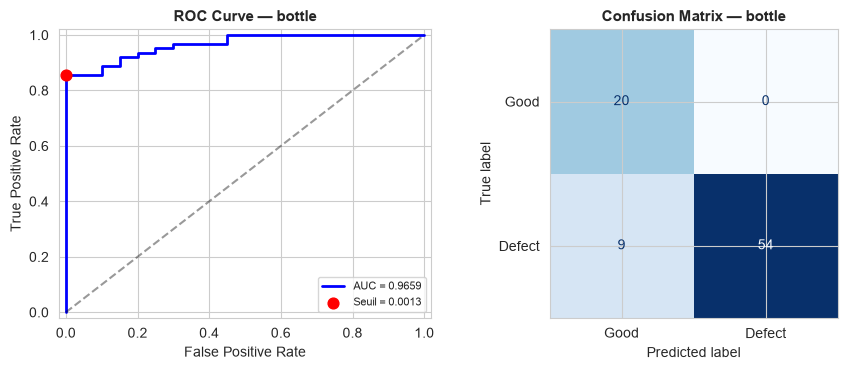


                   🔍 Autoencodeur — cable                   
   Train: 391 | Test: 150 (good: 58, def: 92)

📊 AUC=0.6752 | Loss=0.002403 | 98 epochs | ⏱️ 136.0s
🎯 Seuil optimal = 0.00442
✅ Accuracy=0.6600 | Precision=0.7470 | Recall=0.6739 | F1=0.7086
   VP=62 FP=21 | FN=30 VN=37


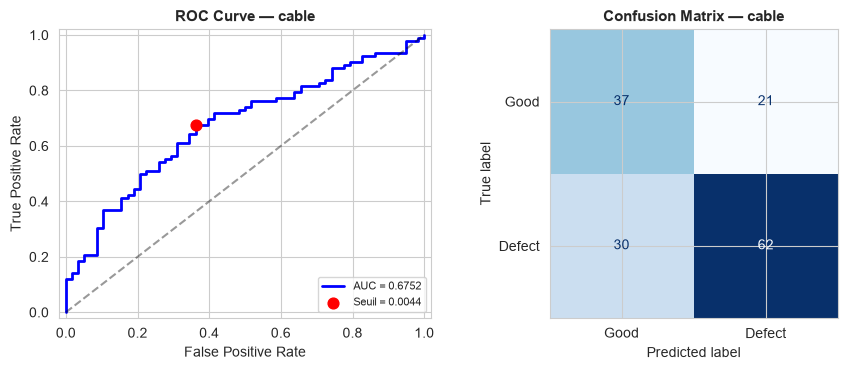


                  🔍 Autoencodeur — capsule                  
   Train: 391 | Test: 132 (good: 23, def: 109)

📊 AUC=0.5780 | Loss=0.000417 | 53 epochs | ⏱️ 71.3s
🎯 Seuil optimal = 0.00086
✅ Accuracy=0.7273 | Precision=0.8544 | Recall=0.8073 | F1=0.8302
   VP=88 FP=15 | FN=21 VN=8


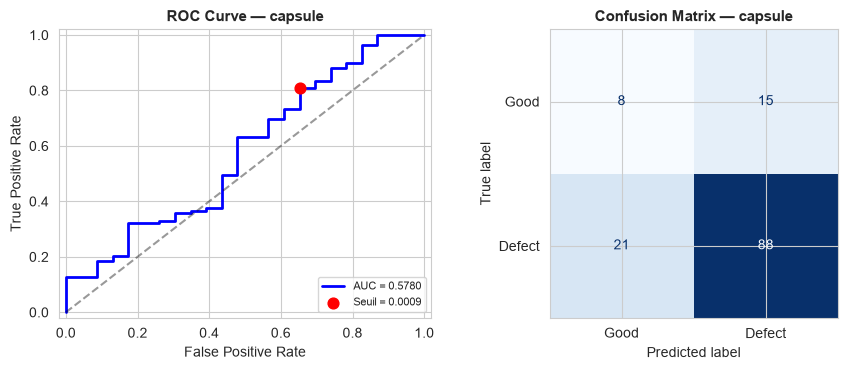


                  🔍 Autoencodeur — carpet                   
   Train: 391 | Test: 117 (good: 28, def: 89)

📊 AUC=0.4823 | Loss=0.002287 | 96 epochs | ⏱️ 123.2s
🎯 Seuil optimal = 0.00487
✅ Accuracy=0.6752 | Precision=0.8000 | Recall=0.7640 | F1=0.7816
   VP=68 FP=17 | FN=21 VN=11


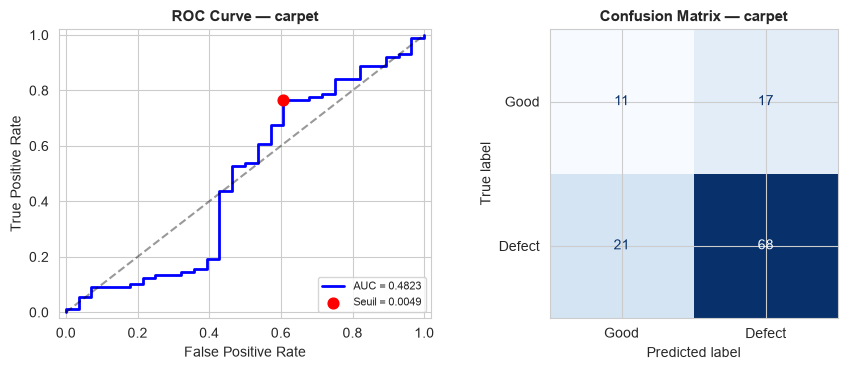


                   🔍 Autoencodeur — grid                    
   Train: 391 | Test: 78 (good: 21, def: 57)

📊 AUC=0.7602 | Loss=0.002590 | 48 epochs | ⏱️ 65.0s
🎯 Seuil optimal = 0.00310
✅ Accuracy=0.8718 | Precision=0.8852 | Recall=0.9474 | F1=0.9153
   VP=54 FP=7 | FN=3 VN=14


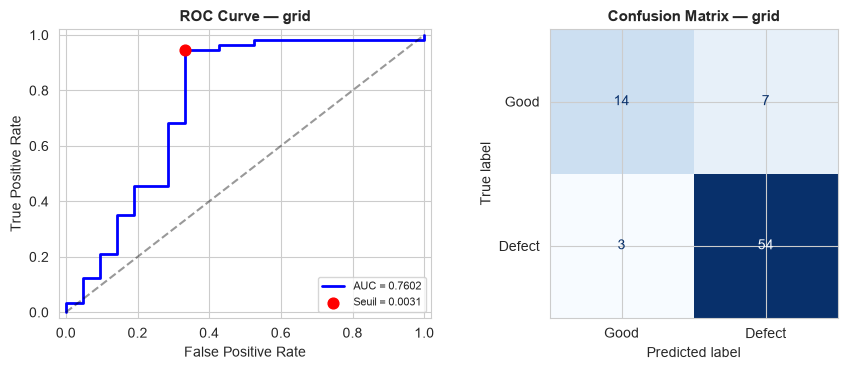


                 🔍 Autoencodeur — hazelnut                  
   Train: 391 | Test: 110 (good: 40, def: 70)

📊 AUC=0.8414 | Loss=0.000504 | 53 epochs | ⏱️ 69.2s
🎯 Seuil optimal = 0.00096
✅ Accuracy=0.7727 | Precision=0.9592 | Recall=0.6714 | F1=0.7899
   VP=47 FP=2 | FN=23 VN=38


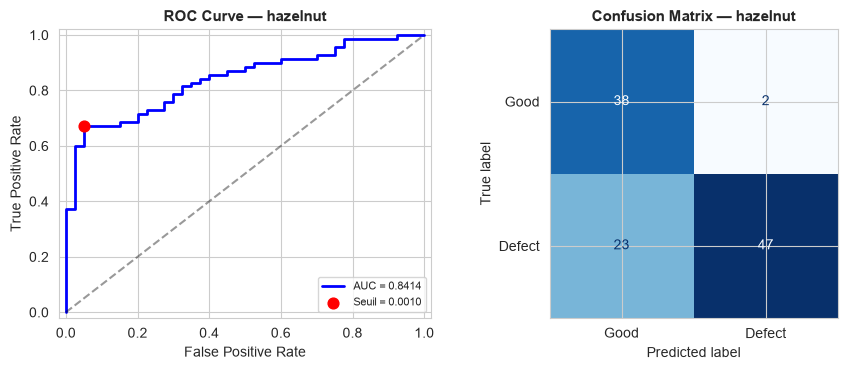


                  🔍 Autoencodeur — leather                  
   Train: 391 | Test: 124 (good: 32, def: 92)

📊 AUC=0.5812 | Loss=0.000309 | 77 epochs | ⏱️ 103.4s
🎯 Seuil optimal = 0.00110
✅ Accuracy=0.4919 | Precision=0.9677 | Recall=0.3261 | F1=0.4878
   VP=30 FP=1 | FN=62 VN=31


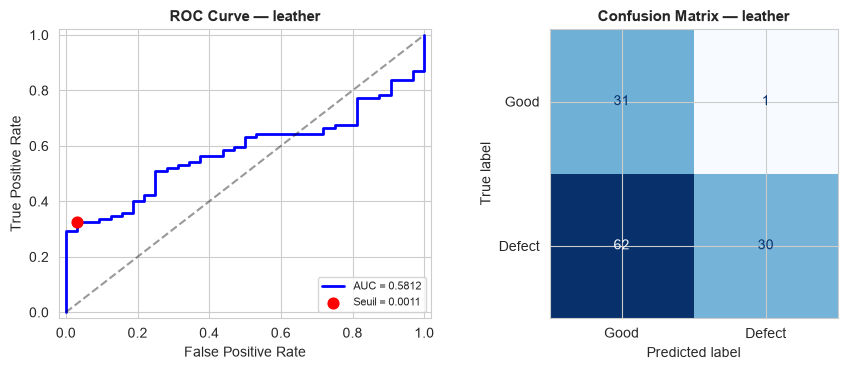


                 🔍 Autoencodeur — metal_nut                 
   Train: 391 | Test: 115 (good: 22, def: 93)

📊 AUC=0.4971 | Loss=0.000966 | 92 epochs | ⏱️ 120.5s
🎯 Seuil optimal = 0.00277
✅ Accuracy=0.3304 | Precision=1.0000 | Recall=0.1720 | F1=0.2936
   VP=16 FP=0 | FN=77 VN=22


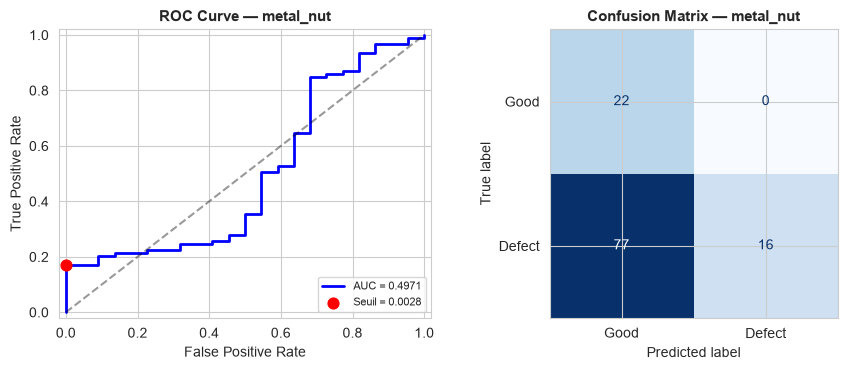


                   🔍 Autoencodeur — pill                    
   Train: 391 | Test: 167 (good: 26, def: 141)

📊 AUC=0.7155 | Loss=0.000457 | 61 epochs | ⏱️ 84.1s
🎯 Seuil optimal = 0.00078
✅ Accuracy=0.5569 | Precision=0.9351 | Recall=0.5106 | F1=0.6606
   VP=72 FP=5 | FN=69 VN=21


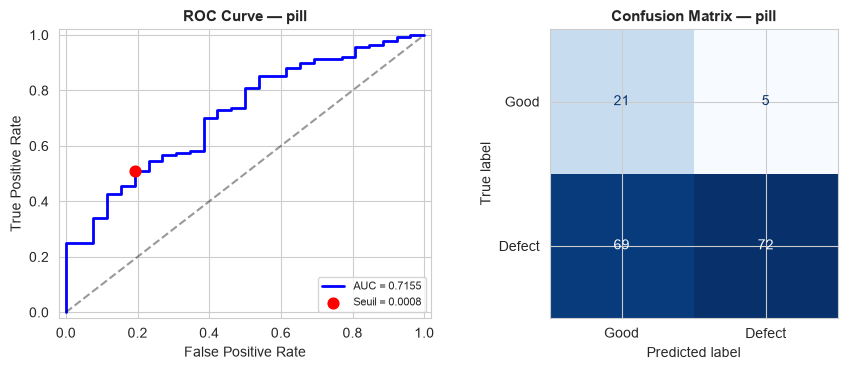


                   🔍 Autoencodeur — screw                   
   Train: 391 | Test: 160 (good: 41, def: 119)

📊 AUC=1.0000 | Loss=0.000341 | 97 epochs | ⏱️ 137.0s
🎯 Seuil optimal = 0.00132
✅ Accuracy=1.0000 | Precision=1.0000 | Recall=1.0000 | F1=1.0000
   VP=119 FP=0 | FN=0 VN=41


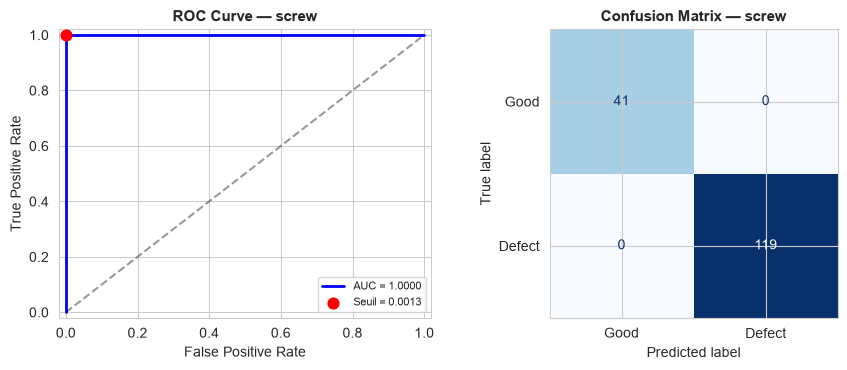


                   🔍 Autoencodeur — tile                    
   Train: 391 | Test: 117 (good: 33, def: 84)

📊 AUC=0.4416 | Loss=0.001773 | 100 epochs | ⏱️ 133.5s
🎯 Seuil optimal = 0.00703
✅ Accuracy=0.3248 | Precision=1.0000 | Recall=0.0595 | F1=0.1124
   VP=5 FP=0 | FN=79 VN=33


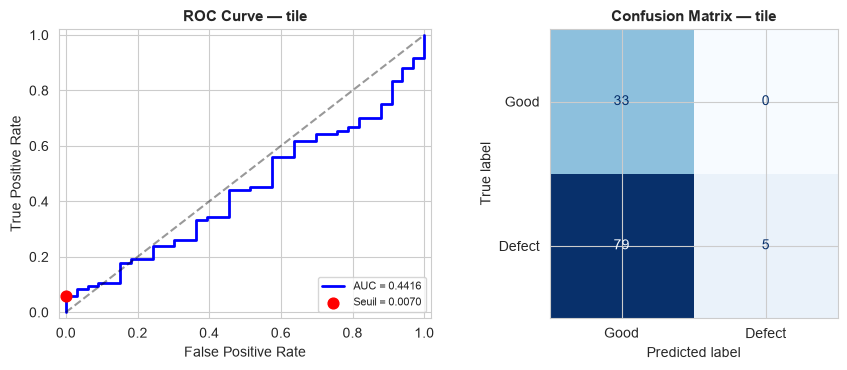


                🔍 Autoencodeur — toothbrush                 
   Train: 391 | Test: 42 (good: 12, def: 30)

📊 AUC=0.9778 | Loss=0.000637 | 72 epochs | ⏱️ 102.7s
🎯 Seuil optimal = 0.00095
✅ Accuracy=0.9286 | Precision=0.9655 | Recall=0.9333 | F1=0.9492
   VP=28 FP=1 | FN=2 VN=11


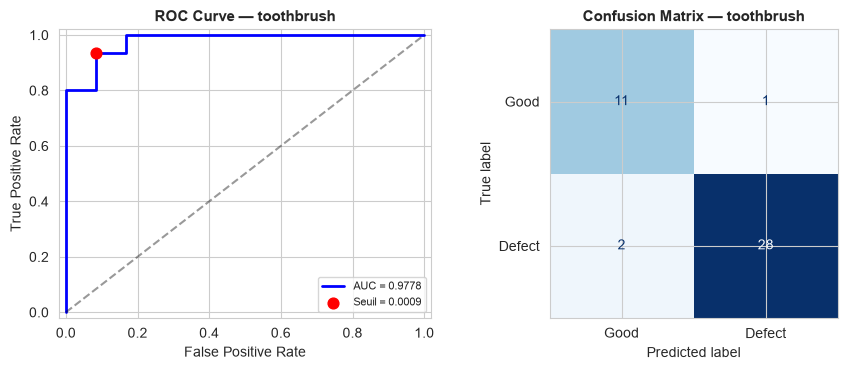


                🔍 Autoencodeur — transistor                 
   Train: 391 | Test: 100 (good: 60, def: 40)

📊 AUC=0.7083 | Loss=0.000638 | 100 epochs | ⏱️ 144.5s
🎯 Seuil optimal = 0.00149
✅ Accuracy=0.7000 | Precision=0.6190 | Recall=0.6500 | F1=0.6341
   VP=26 FP=16 | FN=14 VN=44


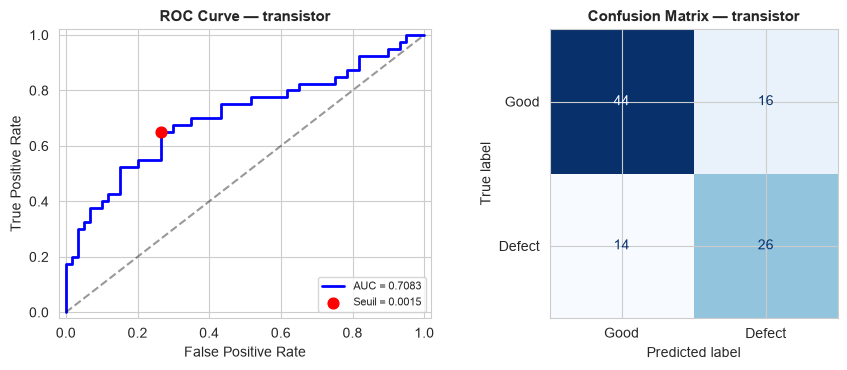


                   🔍 Autoencodeur — wood                    
   Train: 391 | Test: 79 (good: 19, def: 60)

📊 AUC=0.9386 | Loss=0.000594 | 100 epochs | ⏱️ 133.2s
🎯 Seuil optimal = 0.00085
✅ Accuracy=0.8734 | Precision=0.9630 | Recall=0.8667 | F1=0.9123
   VP=52 FP=2 | FN=8 VN=17


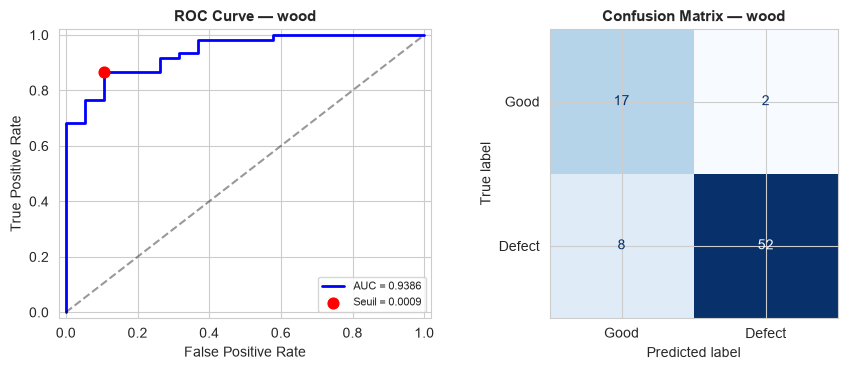


                  🔍 Autoencodeur — zipper                   
   Train: 391 | Test: 151 (good: 32, def: 119)

📊 AUC=0.6079 | Loss=0.001727 | 38 epochs | ⏱️ 56.0s
🎯 Seuil optimal = 0.01946
✅ Accuracy=0.3974 | Precision=0.9667 | Recall=0.2437 | F1=0.3893
   VP=29 FP=1 | FN=90 VN=31


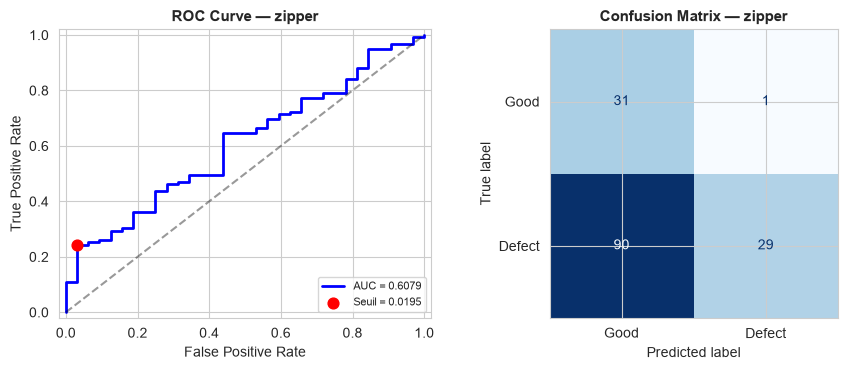



               📊 BENCHMARK Autoencodeur — 15 catégories               
Catégorie            AUC       Loss  Epochs    Temps
------------------------------------------------
bottle            0.9659   0.000797      71    99.5s
cable             0.6752   0.002403      98   136.0s
capsule           0.5780   0.000417      53    71.3s
carpet            0.4823   0.002287      96   123.2s
grid              0.7602   0.002590      48    65.0s
hazelnut          0.8414   0.000504      53    69.2s
leather           0.5812   0.000309      77   103.4s
metal_nut         0.4971   0.000966      92   120.5s
pill              0.7155   0.000457      61    84.1s
screw             1.0000   0.000341      97   137.0s
tile              0.4416   0.001773     100   133.5s
toothbrush        0.9778   0.000637      72   102.7s
transistor        0.7083   0.000638     100   144.5s
wood              0.9386   0.000594     100   133.2s
zipper            0.6079   0.001727      38    56.0s
------------------------------

In [ ]:
# ---- Boucle sur toutes les catégories ----
results = {}       # {catégorie: {"auc": ..., "time": ..., "loss": ...}}
all_preds = {}     # {catégorie: {"errors": ndarray, "y_true": ndarray}}

for category in CATEGORIES:
    print(f"\n{'='*60}")
    print(f"{'🔍 Autoencodeur — ' + category:^60}")
    print(f"{'='*60}")
    t_cat = time.time()
    
    # 1. Chargement
    X_train, X_test, y_test = load_category(BASE_DIR, category)
    print(f"   Train: {X_train.shape[0]} | Test: {X_test.shape[0]} (good: {(y_test==0).sum()}, def: {(y_test==1).sum()})")
    
    # 2. Construction du modèle
    autoencoder = build_autoencoder()
    
    # 3. Compilation
    autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='mse')
    
    callbacks = [
        keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True,
                                      monitor='loss', verbose=0),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6, verbose=0),
    ]
    
    # 4. Entraînement
    history = autoencoder.fit(
        X_train, X_train,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=0  # Silencieux pour 15 catégories
    )
    
    final_loss = history.history['loss'][-1]
    n_epochs = len(history.history['loss'])
    
    # 5. Évaluation
    X_test_pred = autoencoder.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
    reconstruction_errors = np.mean(np.mean((X_test - X_test_pred)**2, axis=(1, 2)), axis=-1)
    auc = roc_auc_score(y_test, reconstruction_errors)
    
    elapsed = time.time() - t_cat
    
    # 6. Métriques détaillées
    # Seuil optimal (Youden's J)
    fpr, tpr, thresholds = roc_curve(y_test, reconstruction_errors)
    youden_j = tpr - fpr
    best_idx = np.argmax(youden_j)
    best_thresh = thresholds[best_idx]
    y_pred = (reconstruction_errors >= best_thresh).astype(int)
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    results[category] = {
        "auc": auc, "time": elapsed, "loss": final_loss, "epochs": n_epochs,
        "accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1,
        "tn": tn, "fp": fp, "fn": fn, "tp": tp, "threshold": best_thresh
    }
    all_preds[category] = {"errors": reconstruction_errors.copy(), "y_true": y_test.copy()}
    
    # ── Affichage des métriques ──
    print(f"\n📊 AUC={auc:.4f} | Loss={final_loss:.6f} | {n_epochs} epochs | ⏱️ {elapsed:.1f}s")
    print(f"🎯 Seuil optimal = {best_thresh:.5f}")
    print(f"✅ Accuracy={accuracy:.4f} | Precision={precision:.4f} | Recall={recall:.4f} | F1={f1:.4f}")
    print(f"   VP={tp} FP={fp} | FN={fn} VN={tn}")
    
    # ── ROC Curve + Confusion Matrix (côte à côte) ──
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.8))
    
    ax1.plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc:.4f}')
    ax1.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax1.scatter(fpr[best_idx], tpr[best_idx], color='red', s=60, zorder=5,
                label=f'Seuil = {best_thresh:.4f}')
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title(f'ROC Curve — {category}', fontsize=11, fontweight='bold')
    ax1.legend(fontsize=8, loc='lower right')
    ax1.set_xlim(-0.02, 1.02)
    ax1.set_ylim(-0.02, 1.02)
    
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Good', 'Defect'],
        cmap='Blues', ax=ax2, colorbar=False, values_format='d'
    )
    ax2.set_title(f'Confusion Matrix — {category}', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# ---- Résumé final ----
print(f"\n\n{'='*70}")
print(f"{'📊 BENCHMARK Autoencodeur — 15 catégories':^70}")
print(f"{'='*70}")
print(f"{'Catégorie':<15} {'AUC':>8} {'Loss':>10} {'Epochs':>7} {'Temps':>8}")
print(f"{'-'*48}")
for cat in CATEGORIES:
    r = results[cat]
    print(f"{cat:<15} {r['auc']:>8.4f} {r['loss']:>10.6f} {r['epochs']:>7} {r['time']:>7.1f}s")
print(f"{'-'*48}")
mean_auc = np.mean([r['auc'] for r in results.values()])
print(f"{'MOYENNE':<15} {mean_auc:>8.4f}")
print(f"{'='*70}")

# Sauvegarde pour comparaison avec VAE
results_ae = results.copy()
print("💾 Résultats sauvegardés dans `results_ae` pour comparaison VAE")

## 5. Synthèse visuelle — Toutes les catégories

Vue d'ensemble des performances avec les 15 matrices de confusion et un tableau comparatif complet.


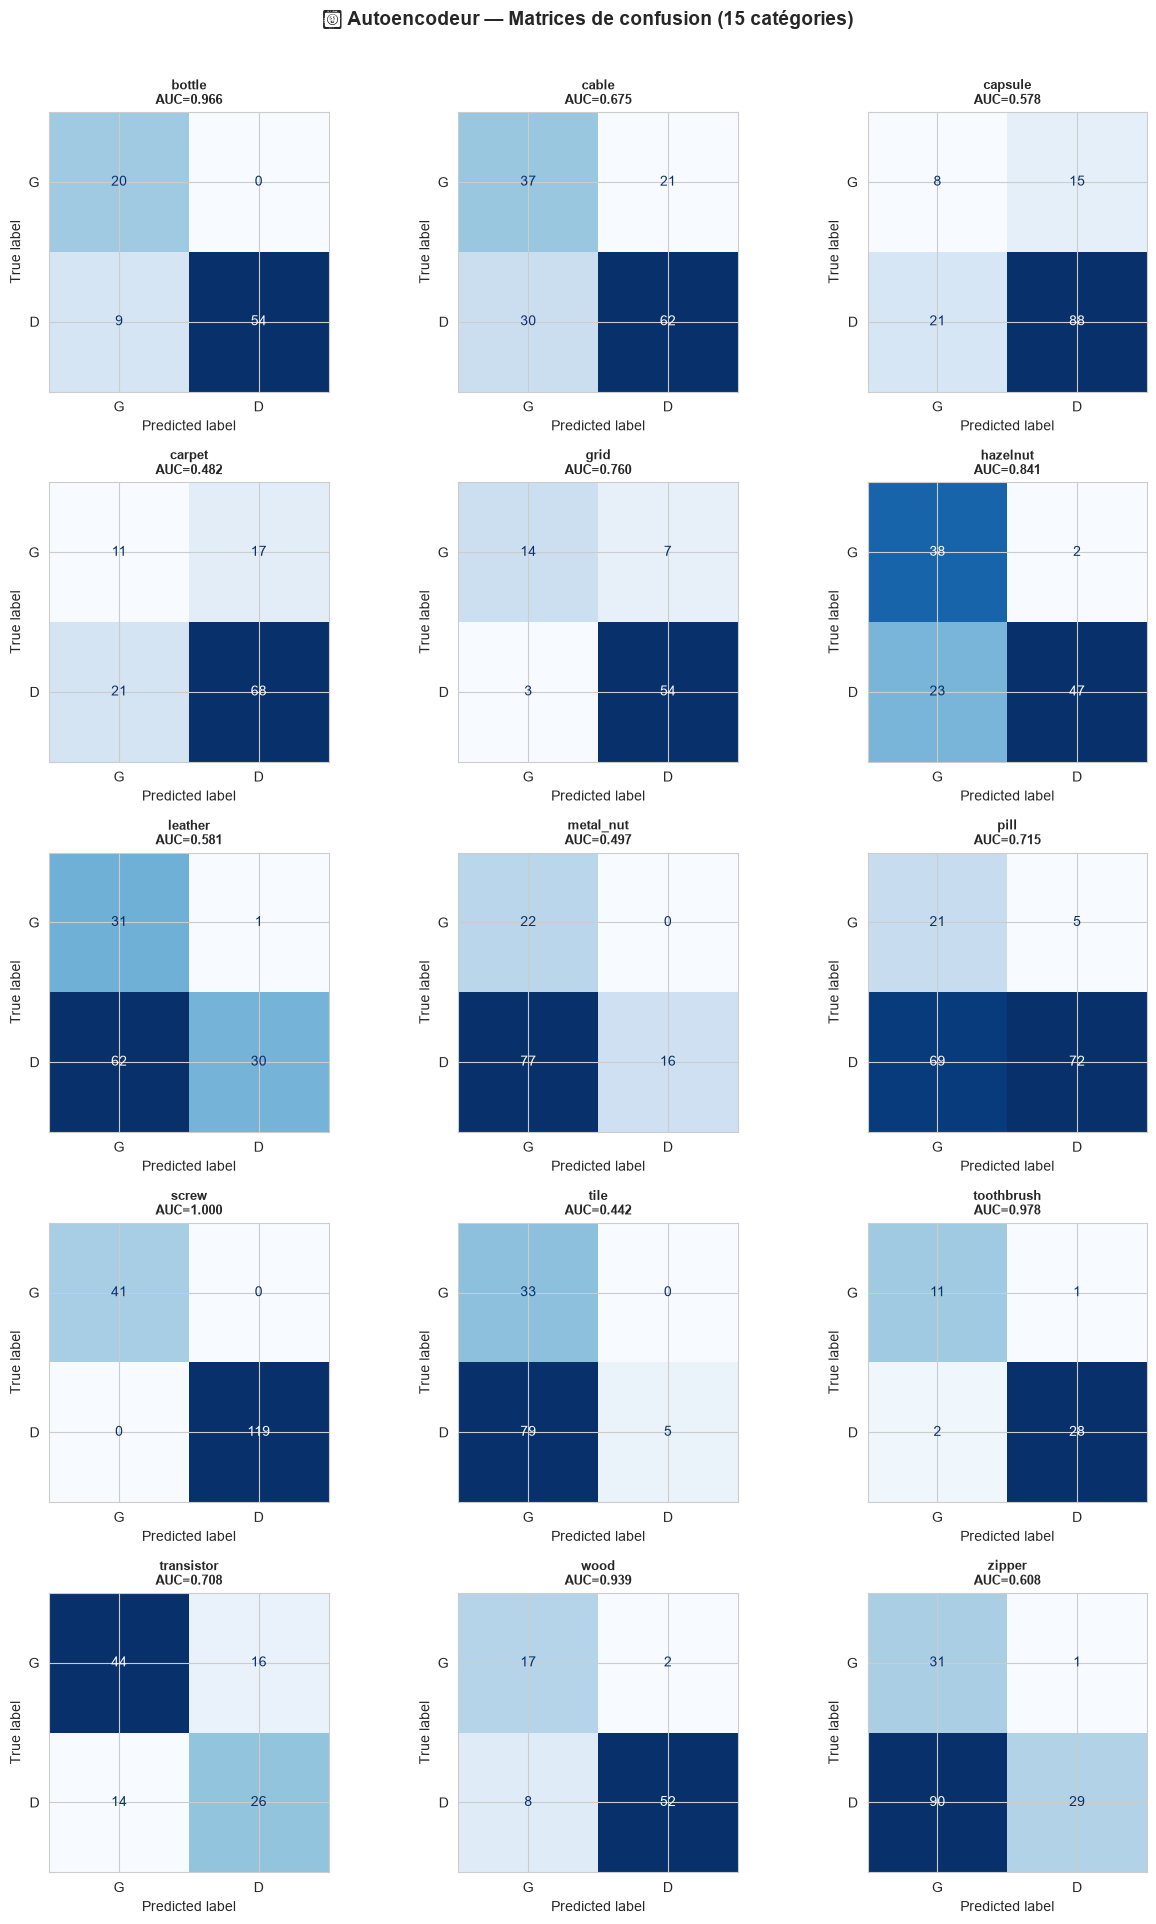


                                 📊 SYNTHÈSE COMPLÈTE — Autoencodeur                                 
Catégorie          AUC     Seuil  Accuracy  Precision   Recall      F1   VP   FP   FN   VN
----------------------------------------------------------------------------------------------------
bottle           0.966   0.00132     0.892      1.000    0.857   0.923   54    0    9   20
cable            0.675   0.00442     0.660      0.747    0.674   0.709   62   21   30   37
capsule          0.578   0.00086     0.727      0.854    0.807   0.830   88   15   21    8
carpet           0.482   0.00487     0.675      0.800    0.764   0.782   68   17   21   11
grid             0.760   0.00310     0.872      0.885    0.947   0.915   54    7    3   14
hazelnut         0.841   0.00096     0.773      0.959    0.671   0.790   47    2   23   38
leather          0.581   0.00110     0.492      0.968    0.326   0.488   30    1   62   31
metal_nut        0.497   0.00277     0.330      1.000    0.172   0.29

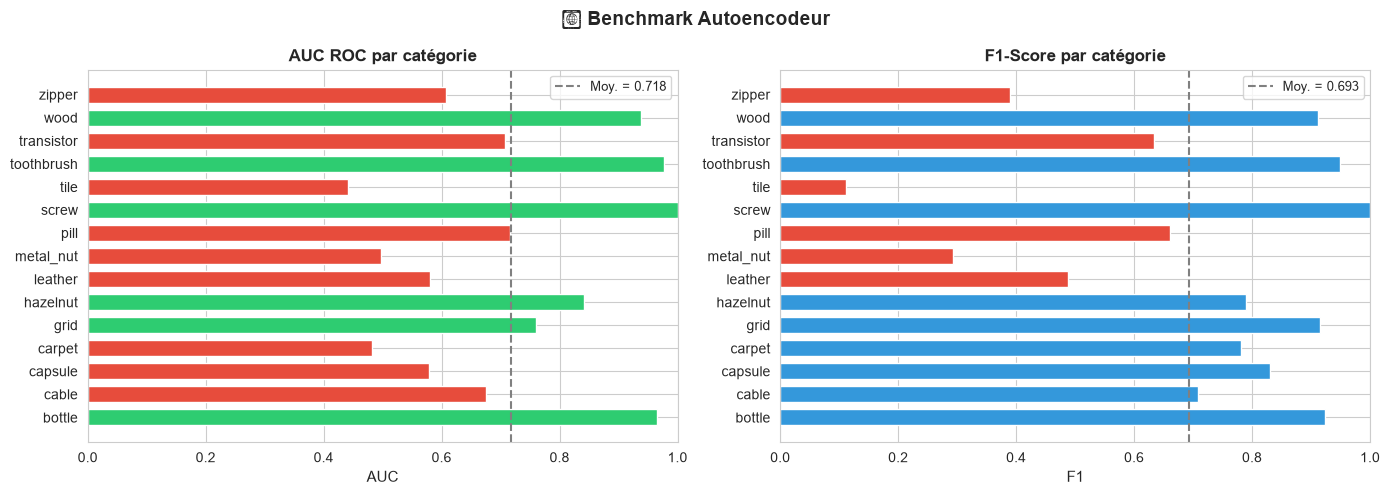

In [6]:
# ─── Synthèse : grille des matrices + histogramme des métriques ───

if 'all_preds' not in dir() or len(all_preds) == 0:
    print("⚠️  `all_preds` est vide. Exécute d'abord la cellule d'entraînement.")
else:
    # ── 1. Grille des 15 matrices de confusion ──
    n_cats = len(CATEGORIES)
    n_cols = 3
    n_rows = int(np.ceil(n_cats / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4.2, n_rows * 3.8))
    axes = axes.flatten()
    
    for idx, cat in enumerate(CATEGORIES):
        ax = axes[idx]
        errors = all_preds[cat]["errors"]
        y_true = all_preds[cat]["y_true"]
        
        fpr, tpr, thresholds = roc_curve(y_true, errors)
        best_t = thresholds[np.argmax(tpr - fpr)]
        y_pred = (errors >= best_t).astype(int)
        
        ConfusionMatrixDisplay.from_predictions(
            y_true, y_pred,
            display_labels=['G', 'D'],
            cmap='Blues', ax=ax, colorbar=False, values_format='d'
        )
        ax.set_title(f'{cat}\nAUC={roc_auc_score(y_true, errors):.3f}',
                     fontsize=9, fontweight='bold')
    
    for idx in range(n_cats, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('🧩 Autoencodeur — Matrices de confusion (15 catégories)',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
    
    # ── 2. Tableau récapitulatif ──
    metrics_list = ['auc', 'accuracy', 'precision', 'recall', 'f1']
    headers = ['Catégorie', 'AUC', 'Seuil', 'Accuracy', 'Precision', 'Recall', 'F1', 'VP', 'FP', 'FN', 'VN']
    
    print(f"\n{'='*100}")
    print(f"{'📊 SYNTHÈSE COMPLÈTE — Autoencodeur':^100}")
    print(f"{'='*100}")
    print(f"{headers[0]:<14} {headers[1]:>7} {headers[2]:>9} {headers[3]:>9} {headers[4]:>10} {headers[5]:>8} {headers[6]:>7} {headers[7]:>4} {headers[8]:>4} {headers[9]:>4} {headers[10]:>4}")
    print(f"{'-'*100}")
    
    all_vals = {k: [] for k in metrics_list}
    for cat in CATEGORIES:
        r = results[cat]
        print(f"{cat:<14} {r['auc']:>7.3f} {r['threshold']:>9.5f} {r['accuracy']:>9.3f} {r['precision']:>10.3f} {r['recall']:>8.3f} {r['f1']:>7.3f} {r['tp']:>4} {r['fp']:>4} {r['fn']:>4} {r['tn']:>4}")
        for k in metrics_list:
            all_vals[k].append(r[k])
    
    print(f"{'-'*100}")
    print(f"{'MOYENNE':<14}", end='')
    for k in metrics_list:
        print(f" {np.mean(all_vals[k]):>7.3f}", end=' ' if k != 'f1' else '')
    print(f"{'':->28}")
    print(f"{'ÉCART-TYPE':<14}", end='')
    for k in metrics_list:
        print(f" {np.std(all_vals[k]):>7.3f}", end=' ' if k != 'f1' else '')
    print()
    print(f"{'='*100}")
    
    # ── 3. Barres horizontales comparatives ──
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for ax, metric, title, color in [
        (axes[0], 'auc', 'AUC ROC', '#2ecc71'),
        (axes[1], 'f1', 'F1-Score', '#3498db')
    ]:
        vals = [results[cat][metric] for cat in CATEGORIES]
        colors = [color if v >= np.mean(vals) else '#e74c3c' for v in vals]
        ax.barh(CATEGORIES, vals, color=colors, edgecolor='white', height=0.7)
        ax.axvline(np.mean(vals), color='gray', linestyle='--',
                    label=f'Moy. = {np.mean(vals):.3f}')
        ax.set_xlabel(metric.upper(), fontsize=11)
        ax.set_title(f'{title} par catégorie', fontsize=12, fontweight='bold')
        ax.set_xlim(0, 1)
        ax.legend(fontsize=9)
    
    plt.suptitle('📊 Benchmark Autoencodeur', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()